In [2]:
# 1. 导入库
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']

In [4]:
# 2. 导入数据
df = pd.read_csv('data/house_sales.csv')

In [5]:
# 3. 数据概览
print('总记录数：',len(df))
print('字段数量：',len(df.columns))
df.head(5)
df.info()

总记录数： 106118
字段数量： 12
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


In [6]:
# 4. 数据清洗
# 删除无用的数据列
df.drop(columns='origin_url', inplace=True)

In [7]:
# 检查是否有缺失值
df.isna().sum()
# 删除缺失值
df.dropna(inplace=True)

In [8]:
# 检查是否有重复值
df.duplicated().sum()
# 删除重复数据
df.drop_duplicates(inplace=True)
# print(len(df))
# 面积的数据类型转换
df['area'] = df['area'].str.replace('㎡','').astype(float)
# 售价的数据类型转换
df['price'] = df['price'].str.replace('万','').astype(float)
# 朝向的数据类型转换
df['toward'] = df['toward'].astype('category')
# 单价的数据类型转换
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)
# 建筑年份的数据类型转换
df['year'] = df['year'].str.replace('年建','').astype(int)

In [9]:
# 异常值的处理
# 房屋面积的异常处理
df = df[ (df['area']<600) & (df['area']>20)]

In [10]:
# 房屋售价的异常处理  IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5*IQR
high_price = Q3 + 1.5*IQR
df = df[ (df['price'] < high_price) & (df['price'] > low_price) ]

In [11]:
# 5. 新数据特征构造
# 地区district
df['district'] = df['address'].str.split('-').str[0]
# 楼层的类型floor_type
df['floor_type'] = df['floor'].str.split('（').str[0].astype('category')
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'
df['floor_type2'] = df['floor'].apply(fun1).astype('category')
# 是否是直辖市zxs
df['zxs'] =  df['city'].apply(lambda x: 1 if x in ['北京','上海','天津','重庆'] else 0)
# 卧室的数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype('int')
# 客厅的数量livingrooms
df['livingrooms'] = df['rooms'].str.extract(r'(\d+)厅').astype('int')
# 楼龄building_age
df['building_age'] = 2025 - df['year']
# 价格的分段price_labels
df['price_labels'] = pd.cut(df['price'],bins=4,labels=['低价','中价','高价','豪华房'])

In [ ]:
# 6. 问题数据及可视化

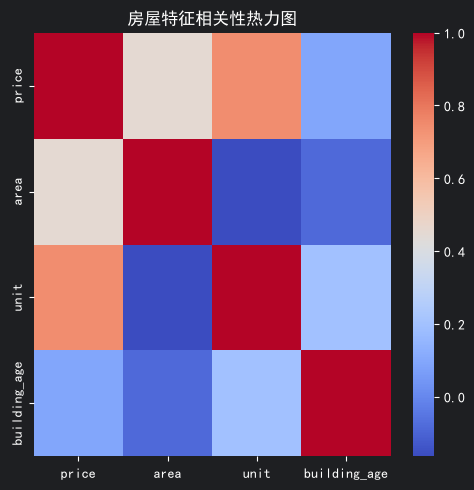

In [12]:
"""
问题:那些变量最影响房价？面积，楼层，房间数哪个影响更大
"""
# 选择数值型特征
a = df[['price','area','unit','building_age']].corr()#相关系数
# 对房价的影响最大的几个因素的排序
a['price'].sort_values(ascending=False)[1:]
# 相关性的热力图
plt.figure(figsize=(5,5))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()
# df.head()

In [14]:
"""
问题：全国房价总体分布是怎样的？是否存在极端值？
"""
df.describe()

,area,price,unit,year,zxs,bedrooms,livingrooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,0.008800,2.714444,1.848556,11.927760
std,33.995994,60.967675,5824.245273,6.019342,0.093399,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,0.000000,2.000000
25%,85.005000,72.000000,7587.000000,2011.000000,0.000000,2.000000,2.000000,8.000000
50%,100.000000,103.000000,10312.000000,2015.000000,0.000000,3.000000,2.000000,10.000000
75%,123.000000,150.000000,14184.000000,2017.000000,0.000000,3.000000,2.000000,14.000000
max,470.000000,306.000000,85288.000000,2023.000000,1.000000,9.000000,12.000000,49.000000


(array([ 991., 4810., 6499., 4613., 3362., 2226., 1333., 1055.,  691.,
         555.]),
 array([  9. ,  38.7,  68.4,  98.1, 127.8, 157.5, 187.2, 216.9, 246.6,
        276.3, 306. ]),
 <BarContainer object of 10 artists>)

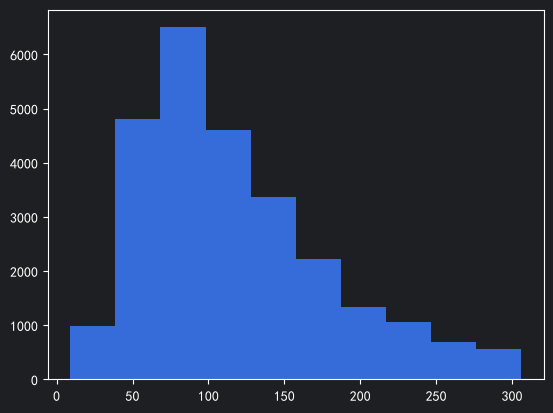

In [15]:
# 房价分布直方图
plt.subplot(111)
plt.hist(df['price'],bins=10)

<Axes: xlabel='price', ylabel='Count'>

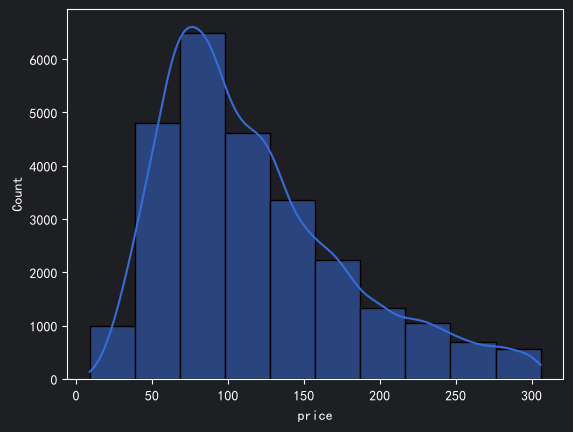

In [25]:
sns.histplot(data=df,x='price',bins=10,kde=True)

In [13]:
"""
问题：南北向是否比单一朝向贵？贵多少
"""
df['toward'].value_counts()
df.groupby('toward').agg({
    'price':['mean','median'],
    'unit':'median',
    'building_age':'mean'
})

price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    12.609524
东南向     115.542608  105.0  10864.0    10.951745
东向      110.158568   95.0  11421.0    12.761337
东西向      98.935099   82.0   9000.0    15.490066
北向       92.527907   75.5  11698.0    13.108527
南北向     119.472147  104.5  10000.0    12.073703
南向      114.555016  103.0  10759.0    11.551160
西北向     119.107594  105.0  12290.0    13.473684
西南向     139.711811  138.4  13333.0    13.452756
西向      102.662298   86.0  12528.0    13.385093

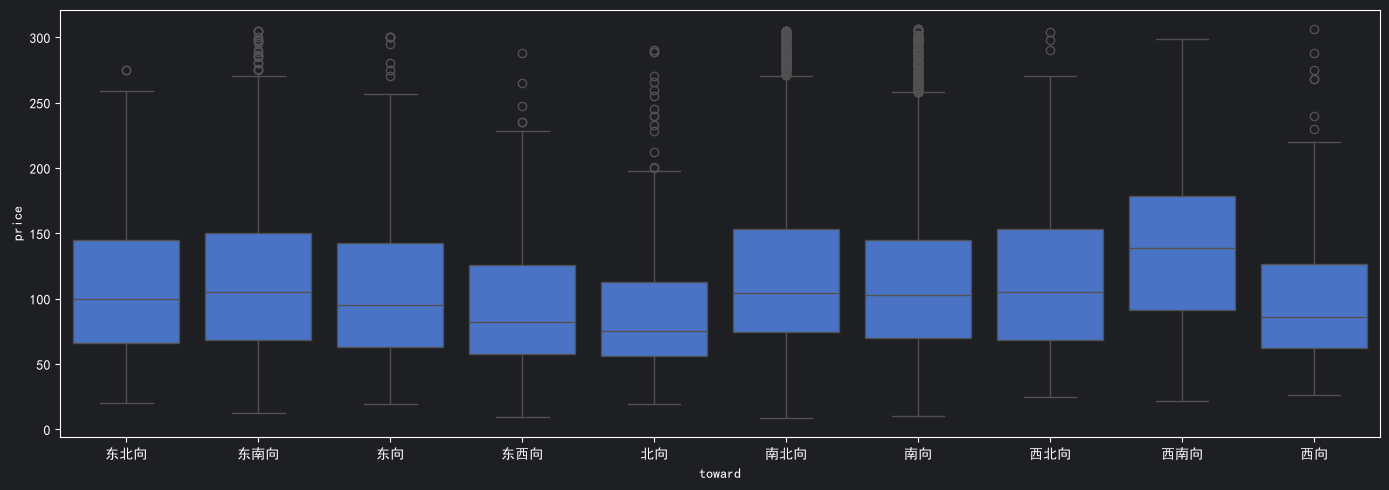

In [32]:
# 数据可视化
plt.figure(figsize=(14,5))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout()